# SCL Mask

This notebook is used to support the development of the SCL mask that we will apply to all bands images to filter out pixels associated to noise.

In [1]:
%load_ext autoreload
%autoreload 2

In [20]:
import os
import sys

sys.path.append(os.path.abspath(".."))

from lulc.io import RAW_DATA_DIR

In [4]:
counter = 0
for root, dirs, files in RAW_DATA_DIR.walk():
    for file in files:
        print(f"{counter}: {file}")
        counter += 1

0: esa_worldcover_grid_composites.fgb
1: S2A_MSIL2A_20220516T110631_N0510_R137_T30STG_20240617T123024_ALLBANDS.tif
2: S2B_MSIL2A_20220531T110619_N0510_R137_T30STG_20240611T141435_ALLBANDS.tif
3: S2A_MSIL2A_20220416T110621_N0510_R137_T30STG_20240526T010916_ALLBANDS.tif
4: S2B_MSIL2A_20220302T110859_N0510_R137_T30STG_20240524T003324_ALLBANDS.tif
5: S2B_MSIL2A_20220421T110619_N0510_R137_T30STG_20240609T214840_ALLBANDS.tif
6: S2A_MSIL2A_20220526T110631_N0510_R137_T30STG_20240615T080108_ALLBANDS.tif
7: S2A_MSIL2A_20220506T110621_N0510_R137_T30STG_20240615T162704_ALLBANDS.tif
8: S2B_MSIL2A_20220131T111209_N0510_R137_T30STG_20240509T043132_ALLBANDS.tif
9: S2A_MSIL2A_20211207T111441_N0500_R137_T30STG_20221228T085814_ALLBANDS.tif
10: S2A_MSIL2A_20220215T111141_N0510_R137_T30STG_20240515T060333_ALLBANDS.tif
11: S2A_MSIL2A_20220106T111441_N0510_R137_T30STG_20240424T232816_ALLBANDS.tif
12: S2B_MSIL2A_20220101T111349_N0510_R137_T30STG_20240419T020830_ALLBANDS.tif
13: S2B_MSIL2A_20211212T111349_N050

We can just select the first file, we don't really care which image we use now:

In [10]:
root, target = next(
    (root, file) for root, _, files in RAW_DATA_DIR.walk() for file in files
)

In [11]:
root, target

(PosixPath('/Users/stepit/Repositories/projects/lu-lc-classification-with-unet/data/raw/MAM'),
 'S2A_MSIL2A_20220516T110631_N0510_R137_T30STG_20240617T123024_ALLBANDS.tif')

In [12]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import rasterio

In [13]:
with rasterio.open(root / target, "r") as src:
    data = src.read()

In [15]:
data.shape

(11, 5181, 5169)

In [19]:
from lulc.config import load_config

In [21]:
cfg = load_config()
scl_band_index = cfg.msi.get_scl_band_index()
mask_classes = cfg.msi.scl_mask_classes

In [22]:
scl = data[scl_band_index]

Now, we want to print the map by using the same colors defined in the [Sentinel Hub](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/scene-classification/):

In [23]:
SCL_CLASSES = {
    0: ("No Data", "#000000"),
    1: ("Saturated or defective", "#ff0000"),
    2: ("Topographic shadows", "#2f2f2f"),
    3: ("Cloud shadows", "#643200"),
    4: ("Vegetation", "#00a000"),
    5: ("Not-vegetated", "#ffe65a"),
    6: ("Water", "#0000ff"),
    7: ("Unclassified", "#808080"),
    8: ("Cloud medium probability", "#c0c0c0"),
    9: ("Cloud high probability", "#ffffff"),
    10: ("Thin cirrus", "#64c8ff"),
    11: ("Snow or ice", "#ff96ff"),
}

# Build a listed colormap aligned to class values
n = max(SCL_CLASSES) + 1
colors = [SCL_CLASSES.get(i, ("", "#000000"))[1] for i in range(n)]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries=range(n + 1), ncolors=n)

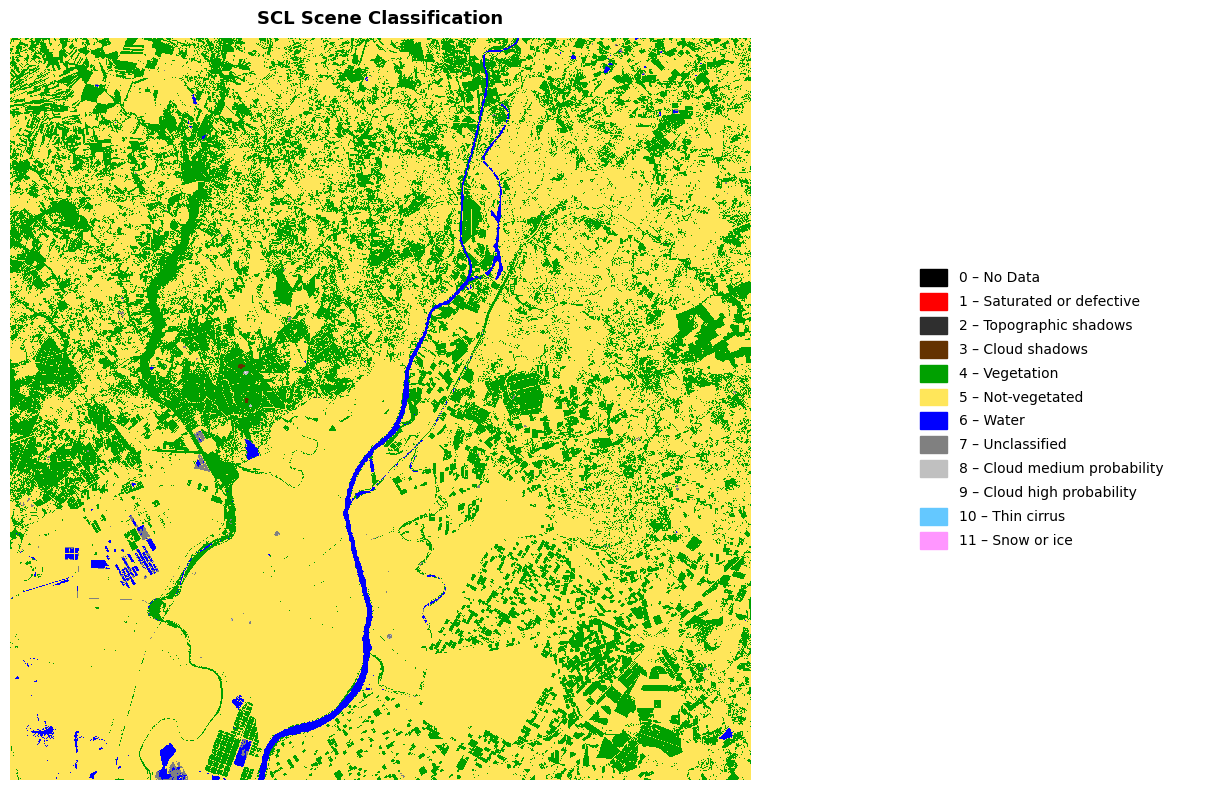

In [24]:
fig, axes = plt.subplots(
    ncols=2, figsize=(14, 8), gridspec_kw={"width_ratios": [3, 1]}, facecolor="white"
)

axes[0].imshow(scl, cmap=cmap, norm=norm, interpolation="none")
axes[0].set_title("SCL Scene Classification", fontsize=13, fontweight="bold", pad=10)
axes[0].axis("off")

import matplotlib.patches as mpatches

patches = [
    mpatches.Patch(color=color, label=f"{v} – {label}")
    for v, (label, color) in SCL_CLASSES.items()
]

axes[1].legend(
    handles=patches,
    loc="center",
    frameon=False,
    fontsize=10,
    handlelength=2,
    handleheight=1.5,
    borderpad=1,
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [25]:
mask_classes

[0, 1, 3, 7, 8, 9, 10, 11]

In [26]:
mask = np.isin(scl, mask_classes)

In [27]:
binary_cmap = mcolors.ListedColormap(["white", "red"])

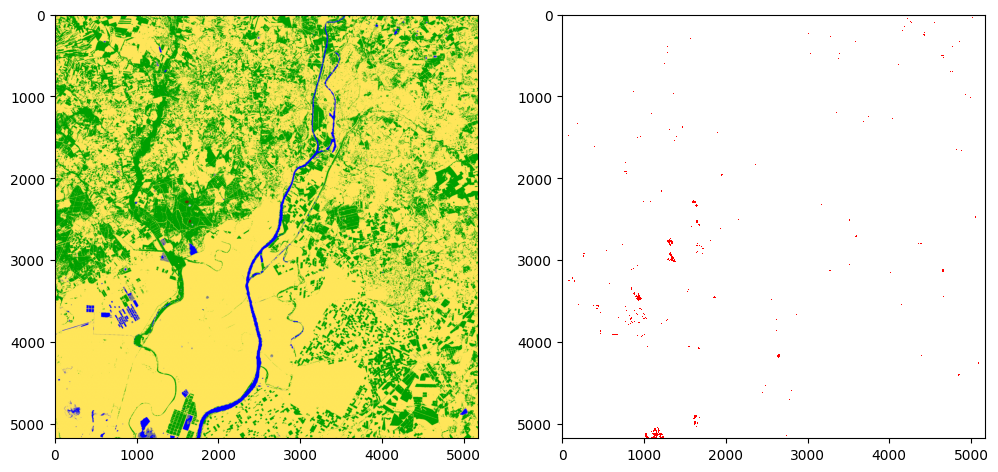

In [28]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 8))
im = ax[0].imshow(scl, cmap=cmap, norm=norm)
ax[1].imshow(mask, cmap=binary_cmap, vmin=0, vmax=1, interpolation="nearest")
plt.show()

Create an RGB

In [29]:
blue = data[0]
green = data[1]
red = data[2]

# Generate the RGB image with channels in the first axis.
rgb = np.stack([red, green, blue], axis=0)

In [30]:
np.isnan(rgb).sum()

np.int64(0)

In [31]:
# Number of True in the mask
mask.sum()

np.int64(61814)

In [32]:
print(data.shape)  # (C, H, W)
print(mask.shape)

(11, 5181, 5169)
(5181, 5169)


In [33]:
# NaN is valid only for float
rgb_masked = rgb.copy().astype(float)
rgb_masked[:, mask] = np.nan

In [37]:
img = np.transpose(rgb_masked, (1, 2, 0))
img = img / 10000.0
img = np.clip(img, 0, 1)

In [ ]:
_, w, g = img.shape
img_resized = img[:, w / 4]

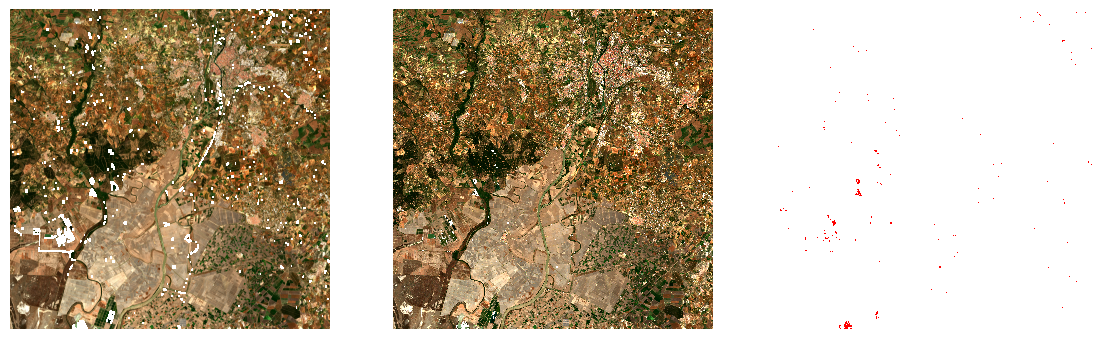

In [38]:
fig, ax = plt.subplots(ncols=3, figsize=(14, 8))
ax[0].imshow(img)
ax[0].axis("off")
ax[1].imshow(img, interpolation="none")
ax[1].axis("off")
ax[2].imshow(mask, cmap=binary_cmap, vmin=0, vmax=1, interpolation="nearest")
ax[2].axis("off")
plt.show()

How much time did I lost to discover that the issue was just matplotlib visualization that interpolated the values?

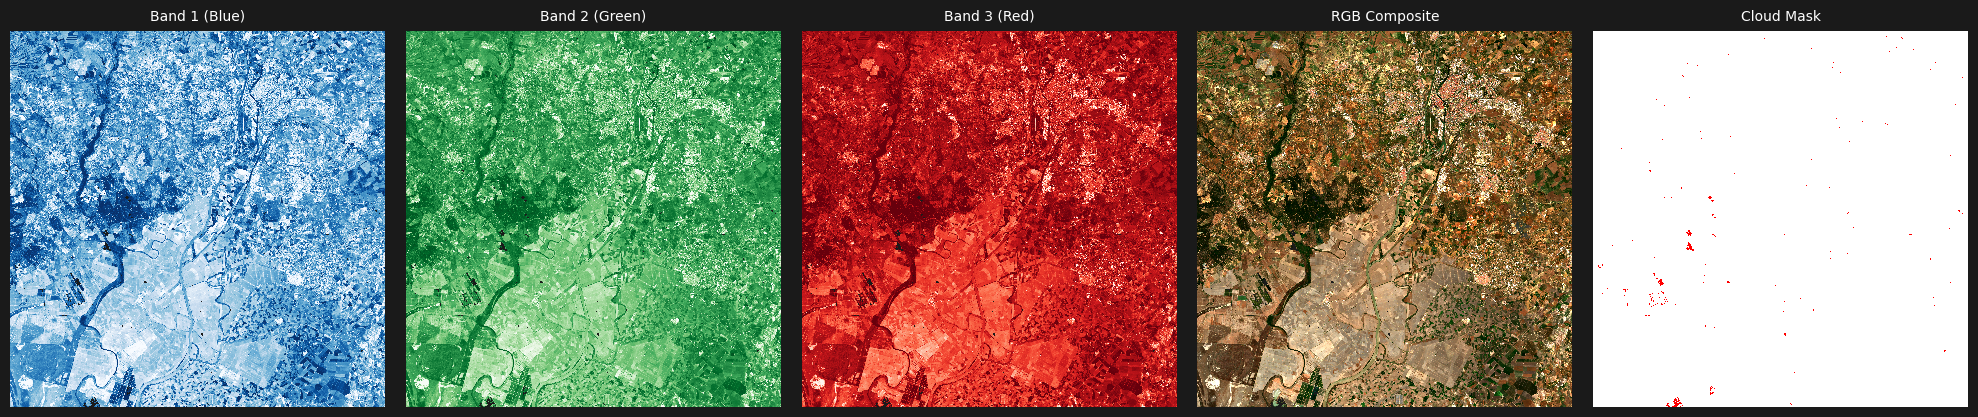

In [39]:
fig, axes = plt.subplots(ncols=5, figsize=(20, 6), facecolor="#1a1a1a")

titles = [
    "Band 1 (Blue)",
    "Band 2 (Green)",
    "Band 3 (Red)",
    "RGB Composite",
    "Cloud Mask",
]

for ax, title in zip(axes, titles):
    ax.set_title(title, color="white", fontsize=10, pad=8)
    ax.axis("off")

axes[0].imshow(img[:, :, 0], cmap="Blues_r", interpolation="none")
axes[1].imshow(img[:, :, 1], cmap="Greens_r", interpolation="none")
axes[2].imshow(img[:, :, 2], cmap="Reds_r", interpolation="none")
axes[3].imshow(img, interpolation="none")
axes[4].imshow(mask, cmap=binary_cmap, vmin=0, vmax=1, interpolation="none")

plt.tight_layout(pad=1.5)
plt.show()